In [6]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os
from netCDF4 import Dataset
from regrid import regrid
import pandas as pd
import cartopy
import cartopy.crs as ccrs
import tqdm
import pickle

https://uitno.app.box.com/s/6ol1xczmmgrv2eupdc7msepuvrk76931?page=2

In [23]:
d1 = Dataset('../SIT/uit_sit_biweekly_v2north_polarstereo_80km_20220723_v3.0.nc')
d2 = Dataset('../SIT/uit_sit_biweekly_v2north_polarstereo_80km_20220807_v3.0.nc')

jl_lon = np.array(d2['longitude'])
jl_lat = np.array(d2['latitude'])
jl_sit = np.array(d2['sea_ice_thickness'])
jl_sno = np.array(d2['snow_depth'])
d2['time_interval']

/tmp/ipykernel_19249/1011151813.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  jl_lon = np.array(d2['longitude'])
/tmp/ipykernel_19249/1011151813.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  jl_lat = np.array(d2['latitude'])
/tmp/ipykernel_19249/1011151813.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration g

<class 'netCDF4.Variable'>
float64 time_interval(time)
    units: days
    comment: number of days over which samples are gridded, centered on "time"
unlimited dimensions: 
current shape = (1,)
filling on, default _FillValue of 9.969209968386869e+36 used

In [13]:
grid_d = Dataset('../aux_data/NSIDC0771_LatLon_PS_N12.5km_v1.1.nc')
lon,lat=np.array(grid_d['longitude']),np.array(grid_d['latitude'])
psn_lon = np.fliplr(np.rot90(np.rot90(lon)))
psn_lat = np.fliplr(np.rot90(np.rot90(lat)))

sit = regrid(jl_sit,jl_lon,jl_lat,psn_lon,psn_lat)
sno = regrid(jl_sno,jl_lon,jl_lat,psn_lon,psn_lat)

/tmp/ipykernel_19249/1050922133.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  lon,lat=np.array(grid_d['longitude']),np.array(grid_d['latitude'])
/home/robbie/custom_modules/regrid.py:19: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  xout, yout = proj.transform(crs_wgs, args, np.array(lon_out),np.array(lat_out))
/home/robbie/custom_modules/regrid.py:21: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  xin, yin = proj.transform(crs_wgs, args, np.array(lon_in),np.array(lat_in))


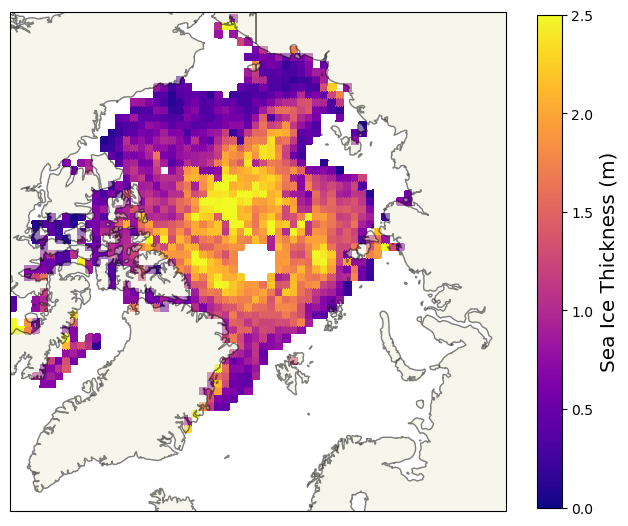

In [15]:
fig = plt.figure(figsize=(8,8))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=0.5)
m = ax.pcolormesh(psn_lon,
                  psn_lat,
                  sit,
                  vmin = 0,
                  vmax = 2.5,
                 transform=ccrs.PlateCarree(),
                  zorder=0,
                  cmap='plasma',
                 )

cb=fig.colorbar(m,shrink=0.8)
cb.set_label('Sea Ice Thickness (m)',fontsize='x-large')
plt.savefig('../figs/sit.png',dpi=500,bbox_inches='tight')

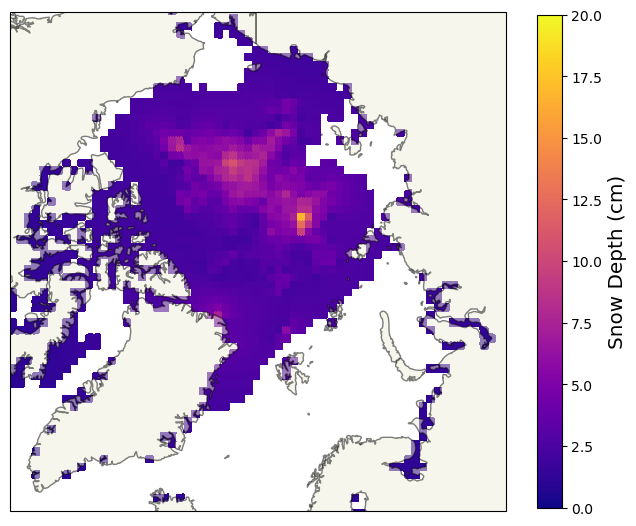

In [18]:
fig = plt.figure(figsize=(8,8))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=0.5)
m = ax.pcolormesh(psn_lon,
                  psn_lat,
                  100*sno,
                  vmin = 0,
                  vmax = 20,
                 transform=ccrs.PlateCarree(),
                  zorder=0,
                  cmap='plasma',
                 )

cb=fig.colorbar(m,shrink=0.8)
cb.set_label('Snow Depth (cm)',fontsize='x-large')
plt.savefig('../figs/snow_depth.png',dpi=500,bbox_inches='tight')